# Minimal Variational Autoencoder (VAE) in NumPy

This notebook implements a simple Variational Autoencoder (VAE) from scratch using only NumPy. We train it on synthetic 2D data to demonstrate:

- How to encode data into a latent space
- How to decode from the latent space back to data
- How to compute and minimize the VAE loss (reconstruction + KL divergence)

No deep learning libraries are used — just NumPy for a clear understanding of the core VAE mechanics.

# Imports & Data

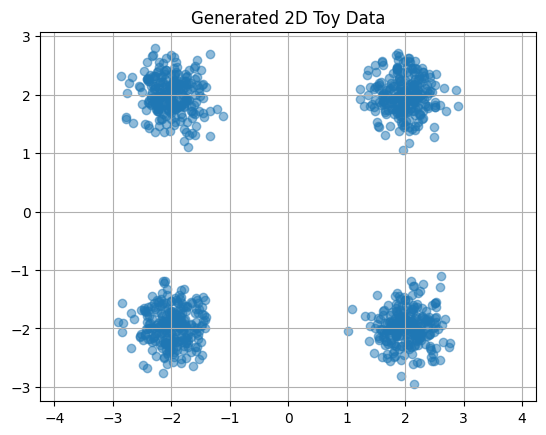

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D Gaussian mixture data
def generate_data(n=1000):
    centers = [np.array([2, 2]), np.array([-2, 2]), np.array([-2, -2]), np.array([2, -2])]
    X = np.vstack([np.random.randn(n // 4, 2) * 0.3 + c for c in centers])
    return X

X = generate_data()
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.title("Generated 2D Toy Data")
plt.axis('equal')
plt.grid(True)
plt.show()

# Activation & Initialization

In [12]:
# ReLU
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# Xavier Init
def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, (in_dim, out_dim))

# Dimensions
input_dim = 2
hidden_dim = 4
latent_dim = 2

# Initialize parameters
params = {
    "W_enc": np.random.randn(input_dim, hidden_dim) * 0.1,
    "b_enc": np.zeros((1, hidden_dim)),
    "W_mu": np.random.randn(hidden_dim, latent_dim) * 0.1,
    "b_mu": np.zeros((1, latent_dim)),
    "W_logvar": np.random.randn(hidden_dim, latent_dim) * 0.1,
    "b_logvar": np.zeros((1, latent_dim)),
    "W_dec": np.random.randn(latent_dim, hidden_dim) * 0.1,
    "b_dec": np.zeros((1, hidden_dim)),
    "W_recon": np.random.randn(hidden_dim, input_dim) * 0.1,
    "b_recon": np.zeros((1, input_dim)),
}

# Encoder, Sampling, Decoder

In [13]:
def encoder(x):
    h = relu(x @ params["W_enc"] + params["b_enc"])
    mu = h @ params["W_mu"] + params["b_mu"]
    logvar = h @ params["W_logvar"] + params["b_logvar"]
    return mu, logvar, h

def sample_z(mu, logvar):
    eps = np.random.randn(*mu.shape)
    return mu + np.exp(0.5 * logvar) * eps

def decoder(z):
    h = relu(z @ params["W_dec"] + params["b_dec"])
    return h @ params["W_recon"] + params["b_recon"]


# Loss Function

In [14]:
def compute_loss(x, x_hat, mu, logvar, kl_weight):
    recon_loss = np.mean(np.sum((x - x_hat)**2, axis=1))
    kl_loss = -0.5 * np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1)
    total_loss = recon_loss + kl_weight * np.mean(kl_loss)
    return total_loss, recon_loss, np.mean(kl_loss)

# Backpropagation

In [15]:
def backward(x, x_hat, mu, logvar, z, h_enc, kl_weight, eps):
    grads = {key: np.zeros_like(val) for key, val in params.items()}

    # Output layer
    dL_dxhat = 2 * (x_hat - x) / x.shape[0]
    h_dec_pre = z @ params["W_dec"] + params["b_dec"]
    h_dec = relu(h_dec_pre)
    dh_dec = dL_dxhat @ params["W_recon"].T * relu_deriv(h_dec_pre)

    grads["W_recon"] = h_dec.T @ dL_dxhat
    grads["b_recon"] = np.sum(dL_dxhat, axis=0, keepdims=True)

    grads["W_dec"] = z.T @ dh_dec
    grads["b_dec"] = np.sum(dh_dec, axis=0, keepdims=True)

    dz = dh_dec @ params["W_dec"].T

    # Backprop through reparameterization
    dmu = dz + kl_weight * mu / x.shape[0]
    dlogvar = kl_weight * 0.5 * (np.exp(logvar) - 1) / x.shape[0] + \
              dz * eps * 0.5 * np.exp(0.5 * logvar)

    # Backprop to encoder
    dmu_h = h_enc.T @ dmu
    dlogvar_h = h_enc.T @ dlogvar

    grads["W_mu"] = h_enc.T @ dmu
    grads["b_mu"] = np.sum(dmu, axis=0, keepdims=True)
    grads["W_logvar"] = h_enc.T @ dlogvar
    grads["b_logvar"] = np.sum(dlogvar, axis=0, keepdims=True)

    dh = (dmu @ params["W_mu"].T) + (dlogvar @ params["W_logvar"].T)
    h_enc_pre = x @ params["W_enc"] + params["b_enc"]
    dh_input = dh * relu_deriv(h_enc_pre)

    grads["W_enc"] = x.T @ dh_input
    grads["b_enc"] = np.sum(dh_input, axis=0, keepdims=True)

    return grads

# Training Loop

In [20]:
learning_rate = 0.01
epochs = 10000
batch_size = 64
num_batches = X.shape[0] // batch_size
losses = []

for epoch in range(epochs):
    perm = np.random.permutation(X.shape[0])
    X_shuffled = X[perm]
    epoch_loss = 0

    kl_weight = min(1.0, epoch / 200)  # Annealing

    for i in range(num_batches):
        x_batch = X_shuffled[i * batch_size:(i + 1) * batch_size]

        mu, logvar, h_enc = encoder(x_batch)
        eps = np.random.randn(*mu.shape)
        z = mu + np.exp(0.5 * logvar) * eps
        x_hat = decoder(z)

        loss, recon, kl = compute_loss(x_batch, x_hat, mu, logvar, kl_weight)
        epoch_loss += loss
        grads = backward(x_batch, x_hat, mu, logvar, z, h_enc, kl_weight, eps)

        for key in params:
            params[key] -= learning_rate * grads[key]

    losses.append(epoch_loss / num_batches)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {losses[-1]:.4f}, Recon: {recon:.4f}, KL: {kl:.4f}")

Epoch 0, Loss: 0.6729, Recon: 0.5694, KL: 1.9706
Epoch 100, Loss: 1.6203, Recon: 0.4046, KL: 2.2718
Epoch 200, Loss: 2.8726, Recon: 2.7356, KL: 2.2067
Epoch 300, Loss: 2.6529, Recon: 0.7720, KL: 1.9202
Epoch 400, Loss: 2.6086, Recon: 0.7319, KL: 1.7852
Epoch 500, Loss: 2.5979, Recon: 0.6774, KL: 1.9477
Epoch 600, Loss: 2.5931, Recon: 0.9393, KL: 1.8632
Epoch 700, Loss: 2.6196, Recon: 0.8555, KL: 1.9160
Epoch 800, Loss: 2.6295, Recon: 0.5839, KL: 1.8122
Epoch 900, Loss: 2.6772, Recon: 0.6454, KL: 1.8748
Epoch 1000, Loss: 2.6633, Recon: 0.6255, KL: 1.8759
Epoch 1100, Loss: 2.5925, Recon: 0.7938, KL: 1.9074
Epoch 1200, Loss: 2.7717, Recon: 0.6907, KL: 1.7517
Epoch 1300, Loss: 2.5228, Recon: 0.6610, KL: 1.9037
Epoch 1400, Loss: 2.6989, Recon: 1.3665, KL: 1.7360
Epoch 1500, Loss: 2.5459, Recon: 0.7765, KL: 1.8018
Epoch 1600, Loss: 2.6105, Recon: 0.6971, KL: 1.7505
Epoch 1700, Loss: 2.8650, Recon: 0.8360, KL: 1.7783
Epoch 1800, Loss: 2.5850, Recon: 0.6449, KL: 1.9081
Epoch 1900, Loss: 2.5792

# Visualization

In [21]:
def plot_reconstructions(X, num_samples=10):
    idx = np.random.choice(X.shape[0], num_samples, replace=False)
    x_sample = X[idx]
    mu, logvar, _ = encoder(x_sample)
    z = sample_z(mu, logvar)
    x_recon = decoder(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], color='lightgray', label='Original Data')
    plt.scatter(x_sample[:, 0], x_sample[:, 1], color='blue', label='Input')
    plt.scatter(x_recon[:, 0], x_recon[:, 1], color='red', marker='x', label='Reconstruction')
    for i in range(num_samples):
        plt.plot([x_sample[i, 0], x_recon[i, 0]], [x_sample[i, 1], x_recon[i, 1]], 'k--', alpha=0.3)
    plt.legend()
    plt.title("Input vs Reconstruction")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

In [22]:
def plot_generated_samples(num_samples=200):
    z = np.random.randn(num_samples, latent_dim)
    x_gen = decoder(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], color='lightgray', label='Training Data')
    plt.scatter(x_gen[:, 0], x_gen[:, 1], color='green', label='Generated')
    plt.legend()
    plt.title("Samples from Latent Space")
    plt.grid(True)
    plt.axis('equal')
    plt.show()


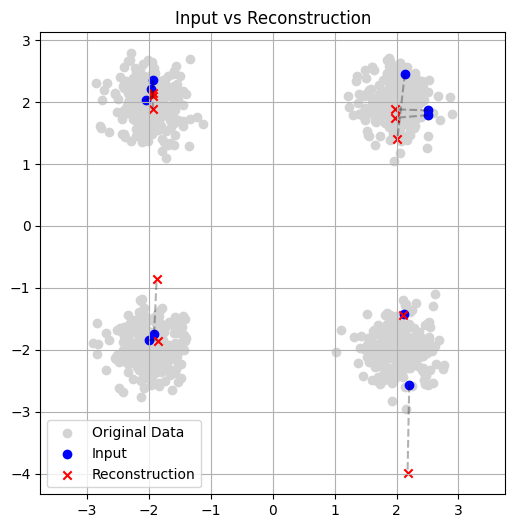

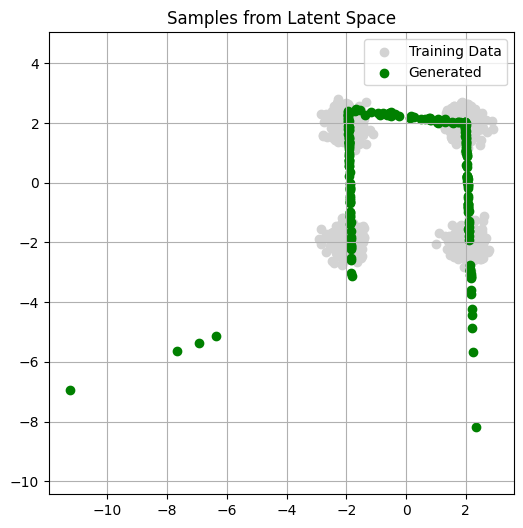

In [23]:
plot_reconstructions(X, num_samples=10)
plot_generated_samples(num_samples=200)